In [30]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt  
import seaborn as sns  

In [31]:
df = pd.read_csv('titanic - titanic.csv')
df.head(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q


<Axes: xlabel='Age'>

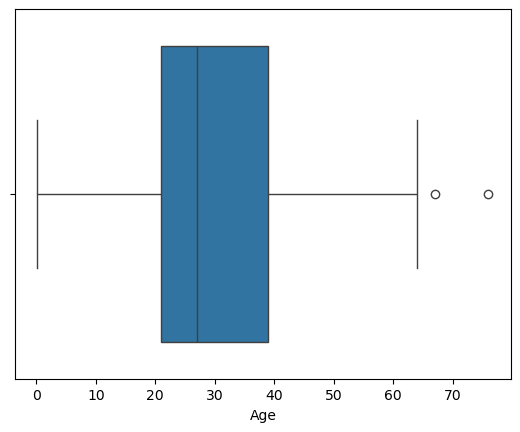

In [32]:
sns.boxplot(x = df['Age'])

In [33]:
percentile25 = df['Age'].quantile(0.25)
percentile75 = df['Age'].quantile(0.75)

In [34]:
percentile25, percentile75

(np.float64(21.0), np.float64(39.0))

In [35]:
IQR = percentile75-percentile25
IQR

np.float64(18.0)

In [36]:
upper_limit = percentile75 + 1.5*IQR 
upper_limit

np.float64(66.0)

In [37]:
lower_limit = 0

In [38]:
# Trimming 

In [39]:
newdf = df[(df['Age']<upper_limit) & (df['Age']>lower_limit)]

In [40]:
# Comparision 

<Axes: xlabel='Age'>

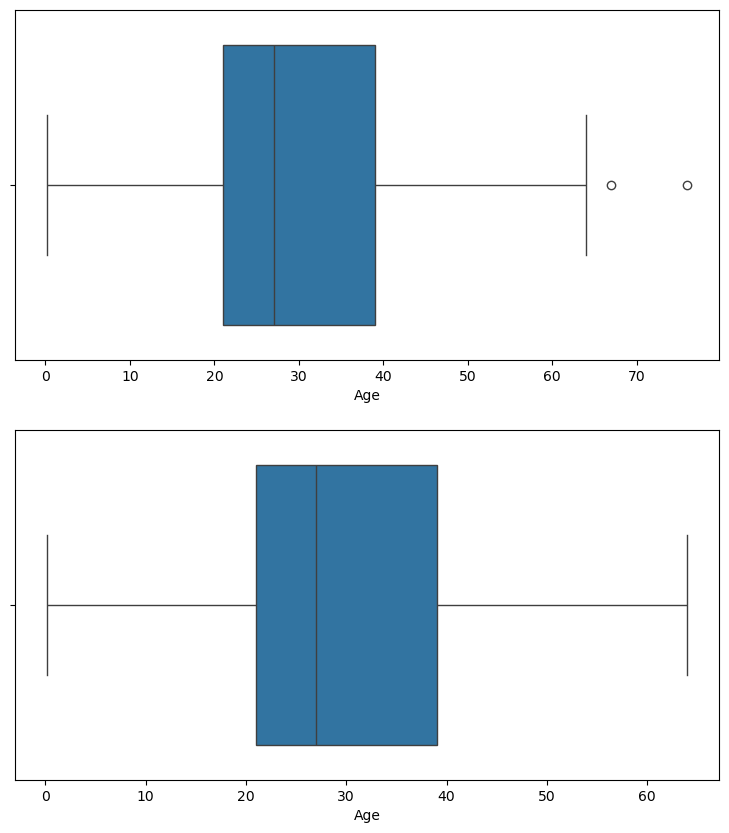

In [41]:
plt.figure(figsize=(20,10))

plt.subplot(222)
sns.boxplot(x=df['Age'])

plt.subplot(224)
sns.boxplot(x=newdf['Age'])

In [42]:
# Capping  

In [43]:
new_df_cap = df.copy()

In [44]:
new_df_cap['Age'] = np.where(
    new_df_cap['Age']>upper_limit, upper_limit,
    np.where(
        new_df_cap['Age']<lower_limit, lower_limit,  
        new_df_cap['Age']
    )
)

<Axes: xlabel='Age'>

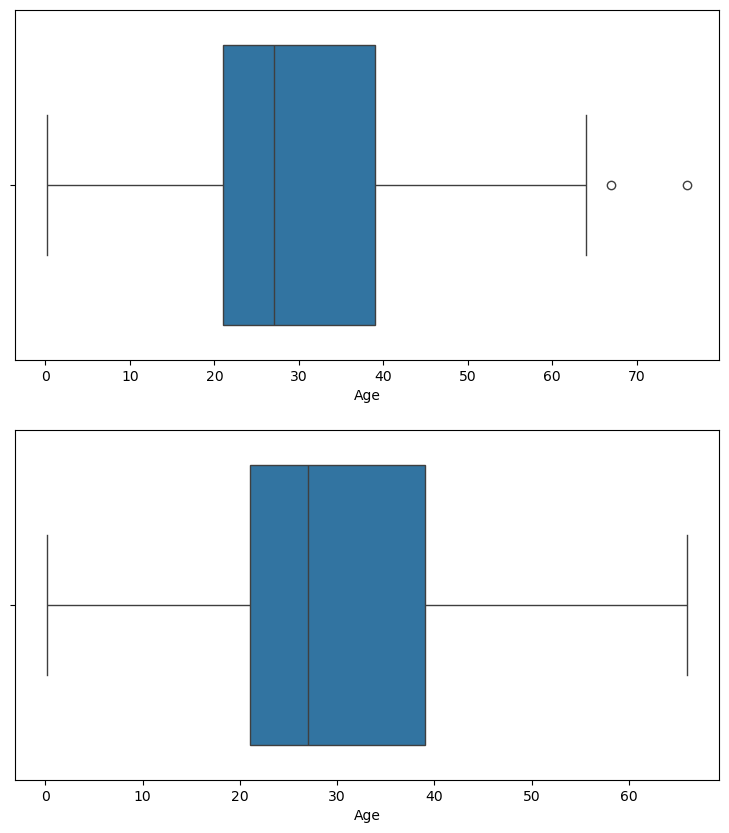

In [45]:
plt.figure(figsize=(20,10))

plt.subplot(222)
sns.boxplot(x=df['Age'])

plt.subplot(224)
sns.boxplot(x=new_df_cap['Age'])